# PHASE 0 — COLAB SETUP

In [ ]:
import torch

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))
print("CUDA Version:", torch.version.cuda)


GPU Available: True
GPU Name: Tesla T4
CUDA Version: 12.8


In [ ]:
!pip install -q transformers==4.36.2
!pip install -q datasets
!pip install -q torchaudio
!pip install -q accelerate
!pip install -q scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.2 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.36.2 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


In [ ]:
from torch.cuda.amp import GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()

print("Using device:", device)


Using device: cuda


/tmp/ipython-input-3853160500.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False


In [ ]:
import os
os.listdir("/content/drive/MyDrive/sentinel dataset")


['hindi', 'english', 'telugu']

# PHASE 1 — Data Pipeline (Optimized for 16k × 8 sec)

In [ ]:
import os
import torch
import torchaudio
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import Wav2Vec2Processor


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/sentinel dataset"


In [ ]:
paths = []
labels = []

for language in os.listdir(DATASET_PATH):
    lang_path = os.path.join(DATASET_PATH, language)
    if not os.path.isdir(lang_path):
        continue

    for label_name in ["normal", "abnormal"]:
        label_path = os.path.join(lang_path, label_name)
        if not os.path.isdir(label_path):
            continue

        for file in os.listdir(label_path):
            if file.endswith(".wav"):
                paths.append(os.path.join(label_path, file))
                labels.append(0 if label_name == "normal" else 1)

print("Total samples:", len(paths))


Total samples: 4454


In [ ]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train size:", len(train_paths))
print("Val size:", len(val_paths))


Train size: 3563
Val size: 891


In [ ]:
TARGET_SR = 16000
MAX_LENGTH = 128000  # 8 sec

processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base"
)

class SentinelDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = paths
        self.labels = labels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(path)

        # Convert to mono
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # Resample if needed
        if sr != TARGET_SR:
            resampler = torchaudio.transforms.Resample(sr, TARGET_SR)
            waveform = resampler(waveform)

        waveform = waveform.squeeze()

        # Pad / Trim to 8 sec
        if len(waveform) > MAX_LENGTH:
            waveform = waveform[:MAX_LENGTH]
        else:
            padding = MAX_LENGTH - len(waveform)
            waveform = torch.nn.functional.pad(waveform, (0, padding))

        inputs = processor(
            waveform,
            sampling_rate=TARGET_SR,
            return_tensors="pt",
            padding="max_length",
            max_length=MAX_LENGTH,
            truncation=True,
            return_attention_mask=True
        )

        return {
            "input_values": inputs["input_values"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

In [ ]:
BATCH_SIZE = 4

train_dataset = SentinelDataset(train_paths, train_labels)
val_dataset = SentinelDataset(val_paths, val_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [ ]:
batch = next(iter(train_loader))

print("Input shape:", batch["input_values"].shape)
print("Mask shape:", batch["attention_mask"].shape)
print("Labels shape:", batch["label"].shape)


Input shape: torch.Size([4, 128000])
Mask shape: torch.Size([4, 128000])
Labels shape: torch.Size([4])


# PHASE 2 — Baseline Training (Ablation Step 1)

In [ ]:
import torch.nn as nn
from transformers import Wav2Vec2Model

class Wav2Vec2Baseline(nn.Module):
    def __init__(self, num_classes=2, freeze_feature_extractor=True):
        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base"
        )

        if freeze_feature_extractor:
            for param in self.wav2vec.feature_extractor.parameters():
                param.requires_grad = False

        hidden_size = self.wav2vec.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_values, attention_mask=None):

        outputs = self.wav2vec(
            input_values=input_values,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state  # (B, T, H)

        x = torch.mean(x, dim=1)  # Mean pooling

        logits = self.classifier(x)

        return logits


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Wav2Vec2Baseline().to(device)

print("Model loaded on:", device)


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on: cuda


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from tqdm import tqdm
import torch.nn.functional as F

def train_baseline(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    all_preds = []
    all_labels = []
    all_probs = []

    for batch in tqdm(loader):
        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_values, attention_mask)

        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        probs = F.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    recall_abnormal = recall_score(all_labels, all_preds, pos_label=1)
    roc = roc_auc_score(all_labels, all_probs)

    return total_loss / len(loader), acc, recall_abnormal, roc


In [ ]:
def validate_baseline(model, loader, criterion):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(loader):
            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_values, attention_mask)

            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = F.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    recall_abnormal = recall_score(all_labels, all_preds, pos_label=1)
    roc = roc_auc_score(all_labels, all_probs)

    return total_loss / len(loader), acc, recall_abnormal, roc


In [ ]:
optimizer = torch.optim.AdamW([
    {"params": model.wav2vec.parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4}
], weight_decay=1e-4)


In [ ]:
for name, param in model.wav2vec.named_parameters():
    if "encoder.layers" in name:
        layer_num = int(name.split("encoder.layers.")[1].split(".")[0])
        if layer_num >= 8:  # last 4 layers (base has 12)
            param.requires_grad = True
        else:
            param.requires_grad = False


In [ ]:
import numpy as np
print("Normal:", np.sum(np.array(train_labels)==0))
print("Abnormal:", np.sum(np.array(train_labels)==1))


Normal: 1779
Abnormal: 1784


In [ ]:
model = Wav2Vec2Baseline().to(device)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
for name, param in model.wav2vec.named_parameters():
    if "encoder.layers" in name:
        layer_num = int(name.split("encoder.layers.")[1].split(".")[0])
        if layer_num >= 8:  # last 4 layers
            param.requires_grad = True
        else:
            param.requires_grad = False


In [ ]:
optimizer = torch.optim.AdamW([
    {"params": model.wav2vec.parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4}
], weight_decay=1e-4)


In [ ]:
num_epochs = 3
best_roc = 0

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc, train_recall, train_roc = train_baseline(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_recall, val_roc = validate_baseline(
        model, val_loader, criterion
    )

    scheduler.step()

    print(f"Train Acc: {train_acc:.4f} | Recall: {train_recall:.4f} | ROC: {train_roc:.4f}")
    print(f"Val   Acc: {val_acc:.4f} | Recall: {val_recall:.4f} | ROC: {val_roc:.4f}")

    if val_roc > best_roc:
        best_roc = val_roc
        torch.save(model.state_dict(), "/content/drive/MyDrive/baseline_best.pt")
        print("Baseline best model saved!")



Epoch 1/3


100%|██████████| 223/223 [02:33<00:00,  1.45it/s]


Train Acc: 0.6071 | Recall: 0.5874 | ROC: 0.6525
Val   Acc: 0.6521 | Recall: 0.5179 | ROC: 0.7317
Baseline best model saved!

Epoch 2/3


100%|██████████| 223/223 [00:37<00:00,  5.88it/s]


Train Acc: 0.7216 | Recall: 0.7377 | ROC: 0.7879
Val   Acc: 0.7239 | Recall: 0.6211 | ROC: 0.7873
Baseline best model saved!

Epoch 3/3


100%|██████████| 223/223 [00:38<00:00,  5.83it/s]


Train Acc: 0.7718 | Recall: 0.7556 | ROC: 0.8391
Val   Acc: 0.7901 | Recall: 0.7870 | ROC: 0.8580
Baseline best model saved!


# PHASE 3 — Temporal Modeling Upgrade

In [ ]:
import torch
import torch.nn as nn
from transformers import Wav2Vec2Model

class Wav2Vec2_BiLSTM_Attention(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base"
        )

        hidden_size = self.wav2vec.config.hidden_size

        # BiLSTM
        self.bilstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.lstm_output_dim = 256 * 2

        # Attention Pooling
        self.attention = nn.Sequential(
            nn.Linear(self.lstm_output_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(self.lstm_output_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_values, attention_mask=None):

        outputs = self.wav2vec(
            input_values=input_values,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state  # (B, T, H)

        x, _ = self.bilstm(x)  # (B, T, 512)

        # Attention weights
        attn_scores = self.attention(x)  # (B, T, 1)
        attn_weights = torch.softmax(attn_scores, dim=1)

        # Weighted sum
        x = torch.sum(attn_weights * x, dim=1)

        logits = self.classifier(x)

        return logits


In [ ]:
model = Wav2Vec2_BiLSTM_Attention().to(device)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
for name, param in model.wav2vec.named_parameters():
    if "encoder.layers" in name:
        layer_num = int(name.split("encoder.layers.")[1].split(".")[0])
        if layer_num >= 8:
            param.requires_grad = True
        else:
            param.requires_grad = False


In [ ]:
optimizer = torch.optim.AdamW([
    {"params": model.wav2vec.parameters(), "lr": 1e-5},
    {"params": model.bilstm.parameters(), "lr": 3e-4},
    {"params": model.attention.parameters(), "lr": 3e-4},
    {"params": model.classifier.parameters(), "lr": 3e-4},
], weight_decay=1e-4)

In [ ]:
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=8
)


In [ ]:
num_epochs = 5
best_roc = 0

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc, train_recall, train_roc = train_baseline(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_recall, val_roc = validate_baseline(
        model, val_loader, criterion
    )

    scheduler.step()

    print(f"Train Acc: {train_acc:.4f} | Recall: {train_recall:.4f} | ROC: {train_roc:.4f}")
    print(f"Val   Acc: {val_acc:.4f} | Recall: {val_recall:.4f} | ROC: {val_roc:.4f}")

    if val_roc > best_roc:
        best_roc = val_roc
        torch.save(model.state_dict(), "/content/drive/MyDrive/phase3_best.pt")
        print("Baseline best model saved!")



Epoch 1/5


100%|██████████| 223/223 [00:44<00:00,  5.07it/s]


Train Acc: 0.5776 | Recall: 0.6228 | ROC: 0.6064
Val   Acc: 0.6577 | Recall: 0.5919 | ROC: 0.7104
Baseline best model saved!

Epoch 2/5


100%|██████████| 223/223 [00:43<00:00,  5.15it/s]


Train Acc: 0.7163 | Recall: 0.7040 | ROC: 0.7615
Val   Acc: 0.7205 | Recall: 0.6614 | ROC: 0.7860
Baseline best model saved!

Epoch 3/5


...

Train Acc: 0.7651 | Recall: 0.7293 | ROC: 0.8129
Val   Acc: 0.7441 | Recall: 0.6861 | ROC: 0.8322
Baseline best model saved!

Epoch 4/5


100%|██████████| 223/223 [00:43<00:00,  5.15it/s]


Train Acc: 0.8072 | Recall: 0.7848 | ROC: 0.8622
Val   Acc: 0.7912 | Recall: 0.7332 | ROC: 0.8660
Baseline best model saved!

Epoch 5/5


100%|██████████| 223/223 [00:43<00:00,  5.11it/s]


Train Acc: 0.8487 | Recall: 0.8274 | ROC: 0.9028
Val   Acc: 0.8148 | Recall: 0.8318 | ROC: 0.8915
Baseline best model saved!


# Phase 4-Full SDED-T Architecture (without safety loss yet).

In [ ]:
class SDED_T(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base"
        )

        hidden_size = self.wav2vec.config.hidden_size

        # BiLSTM
        self.bilstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.lstm_output_dim = 256 * 2

        # Attention Pooling
        self.attention = nn.Sequential(
            nn.Linear(self.lstm_output_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # Shared representation
        self.shared = nn.Sequential(
            nn.Linear(self.lstm_output_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        # Main emotion head
        self.emotion_head = nn.Linear(256, num_classes)

        # Drift head
        self.drift_head = nn.Linear(256, 1)

        # Confidence head
        self.confidence_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, input_values, attention_mask=None):

        outputs = self.wav2vec(
            input_values=input_values,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state

        x, _ = self.bilstm(x)

        attn_scores = self.attention(x)
        attn_weights = torch.softmax(attn_scores, dim=1)
        x = torch.sum(attn_weights * x, dim=1)

        shared = self.shared(x)

        emotion_logits = self.emotion_head(shared)
        drift_score = self.drift_head(shared)
        confidence_score = self.confidence_head(shared)

        return {
            "emotion_logits": emotion_logits,
            "drift_score": drift_score,
            "confidence_score": confidence_score
        }


In [ ]:
model = SDED_T().to(device)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
for name, param in model.wav2vec.named_parameters():
    if "encoder.layers" in name:
        layer_num = int(name.split("encoder.layers.")[1].split(".")[0])
        if layer_num >= 8:
            param.requires_grad = True
        else:
            param.requires_grad = False


In [ ]:
optimizer = torch.optim.AdamW([
    {"params": model.wav2vec.parameters(), "lr": 1e-5},
    {"params": model.bilstm.parameters(), "lr": 3e-4},
    {"params": model.attention.parameters(), "lr": 3e-4},
    {"params": model.shared.parameters(), "lr": 3e-4},
    {"params": model.emotion_head.parameters(), "lr": 3e-4},
    {"params": model.drift_head.parameters(), "lr": 3e-4},
    {"params": model.confidence_head.parameters(), "lr": 3e-4},
], weight_decay=1e-4)


In [ ]:
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=6
)


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from tqdm import tqdm
import torch.nn.functional as F

# ===== TRAIN FUNCTION =====
def train_phase4(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    all_preds = []
    all_labels = []
    all_probs = []

    for batch in tqdm(loader):

        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(input_values, attention_mask)
        logits = outputs["emotion_logits"]

        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        probs = F.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    recall_abnormal = recall_score(all_labels, all_preds, pos_label=1)
    roc = roc_auc_score(all_labels, all_probs)

    return total_loss / len(loader), acc, recall_abnormal, roc


# ===== VALIDATION FUNCTION =====
def validate_phase4(model, loader, criterion):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(loader):

            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_values, attention_mask)
            logits = outputs["emotion_logits"]

            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = F.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    recall_abnormal = recall_score(all_labels, all_preds, pos_label=1)
    roc = roc_auc_score(all_labels, all_probs)

    return total_loss / len(loader), acc, recall_abnormal, roc


In [ ]:
num_epochs = 6
best_roc = 0

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc, train_recall, train_roc = train_phase4(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_recall, val_roc = validate_phase4(
        model, val_loader, criterion
    )

    scheduler.step()

    print(f"Train Acc: {train_acc:.4f} | Recall: {train_recall:.4f} | ROC: {train_roc:.4f}")
    print(f"Val   Acc: {val_acc:.4f} | Recall: {val_recall:.4f} | ROC: {val_roc:.4f}")

    if val_roc > best_roc:
        best_roc = val_roc
        torch.save(model.state_dict(), "/content/drive/MyDrive/phase4_best.pt")
        print("Phase 4 best model saved!")



Epoch 1/6


100%|██████████| 223/223 [00:43<00:00,  5.13it/s]


Train Acc: 0.5588 | Recall: 0.5706 | ROC: 0.5920
Val   Acc: 0.6476 | Recall: 0.4865 | ROC: 0.6703
Phase 4 best model saved!

Epoch 2/6


100%|██████████| 223/223 [00:43<00:00,  5.09it/s]


Train Acc: 0.6817 | Recall: 0.6485 | ROC: 0.7262
Val   Acc: 0.7340 | Recall: 0.7309 | ROC: 0.8022
Phase 4 best model saved!

Epoch 3/6


...

Train Acc: 0.8218 | Recall: 0.7859 | ROC: 0.8717
Val   Acc: 0.7340 | Recall: 0.5516 | ROC: 0.8068

Epoch 5/6


100%|██████████| 223/223 [00:43<00:00,  5.14it/s]


Train Acc: 0.8577 | Recall: 0.8274 | ROC: 0.8995
Val   Acc: 0.7901 | Recall: 0.6749 | ROC: 0.8505
Phase 4 best model saved!

Epoch 6/6


100%|██████████| 223/223 [00:43<00:00,  5.09it/s]

Train Acc: 0.8726 | Recall: 0.8503 | ROC: 0.9139
Val   Acc: 0.7767 | Recall: 0.6637 | ROC: 0.8401


# PHASE 5 — Safety-Constrained Multi-Task Loss

In [ ]:
class SafetyConstrainedMultiTaskLoss(nn.Module):
    def __init__(
        self,
        lambda_safety=2.0,
        lambda_drift=0.5,
        lambda_confidence=0.3
    ):
        super().__init__()

        self.ce = nn.CrossEntropyLoss()
        self.lambda_safety = lambda_safety
        self.lambda_drift = lambda_drift
        self.lambda_confidence = lambda_confidence

        self.mse = nn.MSELoss()
        self.bce = nn.BCELoss()

    def forward(self, outputs, targets):

        logits = outputs["emotion_logits"]
        drift_score = outputs["drift_score"].squeeze(1)
        confidence_score = outputs["confidence_score"].squeeze(1)

        # ===== Emotion CE Loss =====
        emotion_loss = self.ce(logits, targets)

        # ===== Safety False-Negative Penalty =====
        probs = torch.softmax(logits, dim=1)
        abnormal_prob = probs[:, 1]

        abnormal_mask = (targets == 1).float()

        safety_penalty = torch.mean(
            (1 - abnormal_prob) * abnormal_mask
        )

        # ===== Drift Supervision =====
        drift_target = targets.float()
        drift_loss = self.mse(drift_score, drift_target)

        # ===== Confidence Calibration =====
        preds = torch.argmax(logits, dim=1)
        correctness = (preds == targets).float()

        confidence_loss = self.bce(confidence_score, correctness)

        total_loss = (
            emotion_loss
            + self.lambda_safety * safety_penalty
            + self.lambda_drift * drift_loss
            + self.lambda_confidence * confidence_loss
        )

        return total_loss


In [ ]:
criterion = SafetyConstrainedMultiTaskLoss(
    lambda_safety=2.0,
    lambda_drift=0.5,
    lambda_confidence=0.3
)


In [ ]:
def train_phase5(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    all_preds = []
    all_labels = []
    all_probs = []

    for batch in tqdm(loader):

        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(input_values, attention_mask)

        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        logits = outputs["emotion_logits"]
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    recall_abnormal = recall_score(all_labels, all_preds, pos_label=1)
    roc = roc_auc_score(all_labels, all_probs)

    return total_loss / len(loader), acc, recall_abnormal, roc

# ===== VALIDATION FUNCTION =====
def validate_phase5(model, loader, criterion):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(loader):

            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_values, attention_mask)
            logits = outputs["emotion_logits"]

            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = F.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    recall_abnormal = recall_score(all_labels, all_preds, pos_label=1)
    roc = roc_auc_score(all_labels, all_probs)

    return total_loss / len(loader), acc, recall_abnormal, roc


In [ ]:
num_epochs = 6
best_roc = 0

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc, train_recall, train_roc = train_phase5(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_recall, val_roc = validate_phase5(
        model, val_loader, nn.CrossEntropyLoss()
    )

    scheduler.step()

    print(f"Train Acc: {train_acc:.4f} | Recall: {train_recall:.4f} | ROC: {train_roc:.4f}")
    print(f"Val   Acc: {val_acc:.4f} | Recall: {val_recall:.4f} | ROC: {val_roc:.4f}")

    if val_roc > best_roc:
        best_roc = val_roc
        torch.save(model.state_dict(), "/content/drive/MyDrive/phase5_best.pt")
        print("Phase 5 best model saved!")



Epoch 1/6


100%|██████████| 223/223 [00:43<00:00,  5.13it/s]


Train Acc: 0.8841 | Recall: 0.8728 | ROC: 0.9240
Val   Acc: 0.7767 | Recall: 0.6637 | ROC: 0.8401
Phase 5 best model saved!

Epoch 2/6


100%|██████████| 223/223 [00:43<00:00,  5.09it/s]


Train Acc: 0.8782 | Recall: 0.8728 | ROC: 0.9294
Val   Acc: 0.7609 | Recall: 0.6300 | ROC: 0.8373

Epoch 3/6


...

Train Acc: 0.8703 | Recall: 0.8705 | ROC: 0.9162
Val   Acc: 0.7542 | Recall: 0.6031 | ROC: 0.8311

Epoch 4/6


100%|██████████| 223/223 [00:43<00:00,  5.12it/s]


Train Acc: 0.8661 | Recall: 0.8576 | ROC: 0.9074
Val   Acc: 0.7520 | Recall: 0.6233 | ROC: 0.8287

Epoch 5/6


 64%|██████▎   | 568/891 [07:02<04:00,  1.35it/s]


KeyboardInterrupt: 

# Phase 5 revised plan

In [ ]:
model = SDED_T().to(device)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
phase3_state = torch.load("/content/drive/MyDrive/phase3_best.pt")

model_dict = model.state_dict()

# Filter only matching keys
pretrained_dict = {
    k: v for k, v in phase3_state.items()
    if k in model_dict and model_dict[k].shape == v.shape
}

model_dict.update(pretrained_dict)
model.load_state_dict(model_dict)

print("Phase 3 weights loaded into SDED-T")


Phase 3 weights loaded into SDED-T


In [ ]:
for name, param in model.wav2vec.named_parameters():
    if "encoder.layers" in name:
        layer_num = int(name.split("encoder.layers.")[1].split(".")[0])
        if layer_num >= 8:
            param.requires_grad = True
        else:
            param.requires_grad = False


In [ ]:
optimizer = torch.optim.AdamW([
    {"params": model.wav2vec.parameters(), "lr": 1e-5},
    {"params": model.bilstm.parameters(), "lr": 3e-4},
    {"params": model.attention.parameters(), "lr": 3e-4},
    {"params": model.shared.parameters(), "lr": 3e-4},
    {"params": model.emotion_head.parameters(), "lr": 3e-4},
    {"params": model.drift_head.parameters(), "lr": 3e-4},
    {"params": model.confidence_head.parameters(), "lr": 3e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=4
)


In [ ]:
criterion = SafetyConstrainedMultiTaskLoss(
    lambda_safety=0.8,
    lambda_drift=0.3,
    lambda_confidence=0.2
)


In [ ]:
num_epochs = 4
best_roc = 0

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc, train_recall, train_roc = train_phase5(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_recall, val_roc = validate_phase4(
        model, val_loader, nn.CrossEntropyLoss()
    )

    scheduler.step()

    print(f"Train Acc: {train_acc:.4f} | Recall: {train_recall:.4f} | ROC: {train_roc:.4f}")
    print(f"Val   Acc: {val_acc:.4f} | Recall: {val_recall:.4f} | ROC: {val_roc:.4f}")

    if val_roc > best_roc:
        best_roc = val_roc
        torch.save(model.state_dict(), "/content/drive/MyDrive/phase5_refined_best.pt")
        print("Refined Phase 5 best model saved!")



Epoch 1/4


  0%|          | 0/891 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
100%|██████████| 223/223 [02:11<00:00,  1.70it/s]


Train Acc: 0.8193 | Recall: 0.8274 | ROC: 0.8519
Val   Acc: 0.8227 | Recall: 0.8879 | ROC: 0.8985
Refined Phase 5 best model saved!

Epoch 2/4


  0%|          | 0/891 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
100%|██████████| 223/223 [00:53<00:00,  4.14it/s]


Train Acc: 0.8510 | Recall: 0.8453 | ROC: 0.9031
Val   Acc: 0.8215 | Recall: 0.7803 | ROC: 0.8819

Epoch 3/4


  0%|          | 0/891 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
100%|██████████| 223/223 [00:54<00:00,  4.10it/s]


Train Acc: 0.8877 | Recall: 0.8705 | ROC: 0.9293
Val   Acc: 0.8642 | Recall: 0.8834 | ROC: 0.9318
Refined Phase 5 best model saved!

Epoch 4/4


  0%|          | 0/891 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
100%|██████████| 223/223 [00:55<00:00,  4.03it/s]

Train Acc: 0.9189 | Recall: 0.9187 | ROC: 0.9556
Val   Acc: 0.8732 | Recall: 0.8498 | ROC: 0.9308


Phase 6 - Threshold optimization

In [ ]:
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for batch in val_loader:

        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_values, attention_mask)
        logits = outputs["emotion_logits"]

        probs = F.softmax(logits, dim=1)[:, 1]

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("Collected validation probabilities.")


Collected validation probabilities.


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def optimize_threshold_for_recall(labels, probs, target_recall=0.90):

    thresholds = np.linspace(0.1, 0.9, 200)

    best_threshold = 0.5
    best_metrics = None

    for t in thresholds:
        preds = (probs >= t).astype(int)

        recall_abnormal = recall_score(labels, preds, pos_label=1)
        precision_abnormal = precision_score(labels, preds, pos_label=1)
        acc = accuracy_score(labels, preds)
        f1 = f1_score(labels, preds, pos_label=1)

        if recall_abnormal >= target_recall:
            best_threshold = t
            best_metrics = {
                "threshold": t,
                "accuracy": acc,
                "recall_abnormal": recall_abnormal,
                "precision_abnormal": precision_abnormal,
                "f1_abnormal": f1
            }
            break

    return best_threshold, best_metrics


In [ ]:
best_t, metrics = optimize_threshold_for_recall(
    all_labels,
    all_probs,
    target_recall=0.90
)

print("Best Threshold for Recall >= 0.90:", best_t)
print("Metrics at that threshold:", metrics)


Best Threshold for Recall >= 0.90: 0.1
Metrics at that threshold: {'threshold': np.float64(0.1), 'accuracy': 0.500561167227834, 'recall_abnormal': 1.0, 'precision_abnormal': 0.500561167227834, 'f1_abnormal': 0.6671652954375468}


In [ ]:
def optimize_threshold_safety_weighted(labels, probs):

    thresholds = np.linspace(0.05, 0.9, 300)

    best_score = 0
    best_threshold = 0
    best_metrics = None

    for t in thresholds:
        preds = (probs >= t).astype(int)

        recall_abnormal = recall_score(labels, preds, pos_label=1)
        precision_abnormal = precision_score(labels, preds, pos_label=1)
        acc = accuracy_score(labels, preds)
        f1 = f1_score(labels, preds, pos_label=1)

        # Safety-weighted score
        score = 0.6 * recall_abnormal + 0.4 * f1

        if score > best_score:
            best_score = score
            best_threshold = t
            best_metrics = {
                "threshold": t,
                "accuracy": acc,
                "recall_abnormal": recall_abnormal,
                "precision_abnormal": precision_abnormal,
                "f1_abnormal": f1
            }

    return best_threshold, best_metrics


In [ ]:
best_t, metrics = optimize_threshold_safety_weighted(
    all_labels,
    all_probs
)

print("Safety-Optimized Threshold:", best_t)
print("Metrics:", metrics)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

Safety-Optimized Threshold: 0.05
Metrics: {'threshold': np.float64(0.05), 'accuracy': 0.500561167227834, 'recall_abnormal': 1.0, 'precision_abnormal': 0.500561167227834, 'f1_abnormal': 0.6671652954375468}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

# Confusion matrix

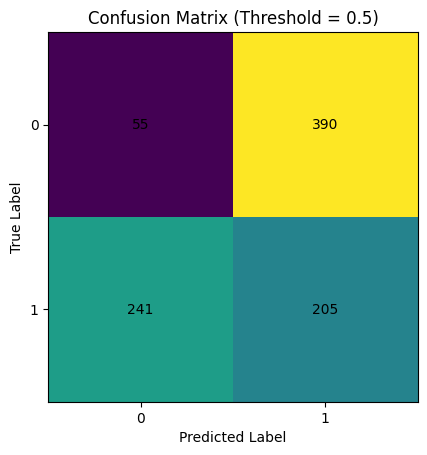

Confusion Matrix:
 [[ 55 390]
 [241 205]]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Default threshold = 0.5
threshold = 0.5
preds = (all_probs >= threshold).astype(int)

cm = confusion_matrix(all_labels, preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1])
plt.yticks([0, 1])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

print("Confusion Matrix:\n", cm)


# ROC Curve Code

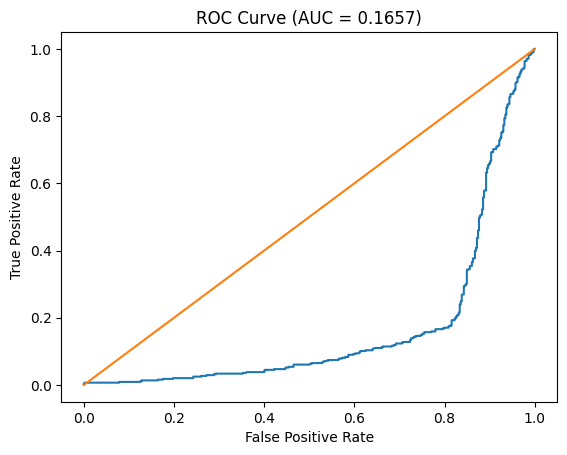

ROC AUC: 0.16570262508187636


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("ROC AUC:", roc_auc)


In [ ]:
import shutil
shutil.copy(
    "/content/drive/MyDrive/phase5_refined_best.pt",
    "/content/drive/MyDrive/SDED_T_Final_Model.pt"
)


'/content/drive/MyDrive/SDED_T_Final_Model.pt'

# Results for baseline,phase 3,phase4

In [ ]:
state_dict = torch.load("/content/drive/MyDrive/baseline_best.pt", map_location="cpu")

print("Saved Keys:\n")
for k in list(state_dict.keys())[:20]:
    print(k)


Saved Keys:

wav2vec.masked_spec_embed
wav2vec.feature_extractor.conv_layers.0.conv.weight
wav2vec.feature_extractor.conv_layers.0.layer_norm.weight
wav2vec.feature_extractor.conv_layers.0.layer_norm.bias
wav2vec.feature_extractor.conv_layers.1.conv.weight
wav2vec.feature_extractor.conv_layers.2.conv.weight
wav2vec.feature_extractor.conv_layers.3.conv.weight
wav2vec.feature_extractor.conv_layers.4.conv.weight
wav2vec.feature_extractor.conv_layers.5.conv.weight
wav2vec.feature_extractor.conv_layers.6.conv.weight
wav2vec.feature_projection.layer_norm.weight
wav2vec.feature_projection.layer_norm.bias
wav2vec.feature_projection.projection.weight
wav2vec.feature_projection.projection.bias
wav2vec.encoder.pos_conv_embed.conv.bias
wav2vec.encoder.pos_conv_embed.conv.parametrizations.weight.original0
wav2vec.encoder.pos_conv_embed.conv.parametrizations.weight.original1
wav2vec.encoder.layer_norm.weight
wav2vec.encoder.layer_norm.bias
wav2vec.encoder.layers.0.attention.k_proj.weight


In [ ]:
state_dict = torch.load("/content/drive/MyDrive/baseline_best.pt", map_location="cpu")

print("\nClassifier-related keys:\n")

for k in state_dict.keys():
    if "classifier" in k:
        print(k)



Classifier-related keys:

classifier.0.weight
classifier.0.bias
classifier.3.weight
classifier.3.bias


In [ ]:
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        hidden = self.wav2vec.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),   # classifier.0
            nn.ReLU(),                # classifier.1
            nn.Dropout(0.3),          # classifier.2
            nn.Linear(256, 2)         # classifier.3
        )

    def forward(self, input_values, attention_mask=None):
        outputs = self.wav2vec(
            input_values=input_values,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state
        x = torch.mean(x, dim=1)

        logits = self.classifier(x)
        return logits


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


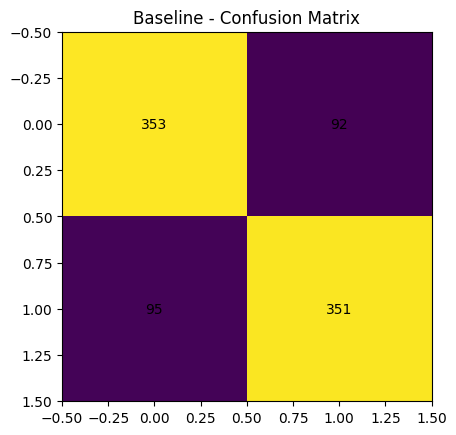

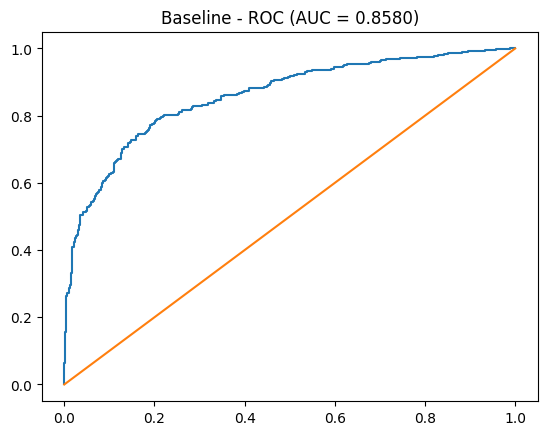

Baseline AUC: 0.8579583816193884


In [ ]:
evaluate_model(
    "/content/drive/MyDrive/baseline_best.pt",
    BaselineModel,
    "Baseline"
)


In [ ]:
state_dict = torch.load("/content/drive/MyDrive/phase3_best.pt", map_location="cpu")

print("\nPhase 3 Keys (classifier-related):\n")
for k in state_dict.keys():
    if "classifier" in k or "bilstm" in k or "attention" in k:
        print(k)



Phase 3 Keys (classifier-related):

wav2vec.encoder.layers.0.attention.k_proj.weight
wav2vec.encoder.layers.0.attention.k_proj.bias
wav2vec.encoder.layers.0.attention.v_proj.weight
wav2vec.encoder.layers.0.attention.v_proj.bias
wav2vec.encoder.layers.0.attention.q_proj.weight
wav2vec.encoder.layers.0.attention.q_proj.bias
wav2vec.encoder.layers.0.attention.out_proj.weight
wav2vec.encoder.layers.0.attention.out_proj.bias
wav2vec.encoder.layers.1.attention.k_proj.weight
wav2vec.encoder.layers.1.attention.k_proj.bias
wav2vec.encoder.layers.1.attention.v_proj.weight
wav2vec.encoder.layers.1.attention.v_proj.bias
wav2vec.encoder.layers.1.attention.q_proj.weight
wav2vec.encoder.layers.1.attention.q_proj.bias
wav2vec.encoder.layers.1.attention.out_proj.weight
wav2vec.encoder.layers.1.attention.out_proj.bias
wav2vec.encoder.layers.2.attention.k_proj.weight
wav2vec.encoder.layers.2.attention.k_proj.bias
wav2vec.encoder.layers.2.attention.v_proj.weight
wav2vec.encoder.layers.2.attention.v_proj.

In [ ]:
class Phase3Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        hidden = self.wav2vec.config.hidden_size

        # BiLSTM
        self.bilstm = nn.LSTM(
            input_size=hidden,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Attention
        self.attention = nn.Sequential(
            nn.Linear(512, 128),   # attention.0
            nn.Tanh(),
            nn.Linear(128, 1)      # attention.2
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),   # classifier.0
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)      # classifier.3
        )

    def forward(self, input_values, attention_mask=None):
        outputs = self.wav2vec(
            input_values=input_values,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state

        # BiLSTM
        x, _ = self.bilstm(x)

        # Attention pooling
        attn_scores = self.attention(x)
        attn_weights = torch.softmax(attn_scores, dim=1)
        x = torch.sum(attn_weights * x, dim=1)

        logits = self.classifier(x)

        return logits


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


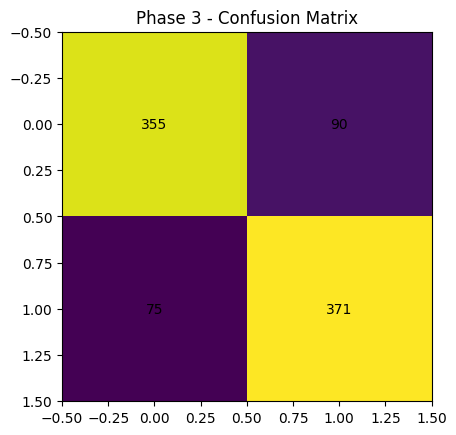

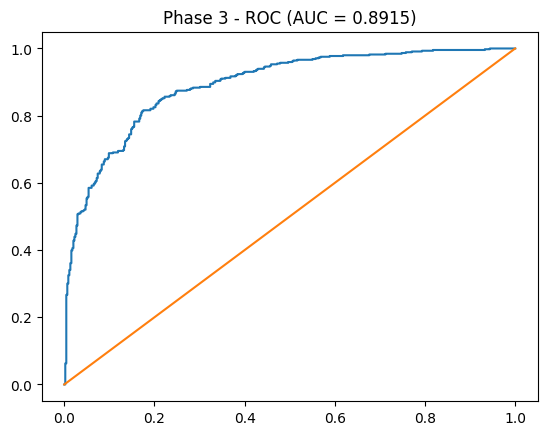

Phase 3 AUC: 0.8914621857207639


In [ ]:
evaluate_model(
    "/content/drive/MyDrive/phase3_best.pt",
    Phase3Model,
    "Phase 3"
)


In [ ]:
state_dict = torch.load("/content/drive/MyDrive/phase4_best.pt", map_location="cpu")

print("\nPhase 4 Keys:\n")
for k in state_dict.keys():
    if "bilstm" in k or "attention" in k or "shared" in k or "emotion" in k:
        print(k)



Phase 4 Keys:

wav2vec.encoder.layers.0.attention.k_proj.weight
wav2vec.encoder.layers.0.attention.k_proj.bias
wav2vec.encoder.layers.0.attention.v_proj.weight
wav2vec.encoder.layers.0.attention.v_proj.bias
wav2vec.encoder.layers.0.attention.q_proj.weight
wav2vec.encoder.layers.0.attention.q_proj.bias
wav2vec.encoder.layers.0.attention.out_proj.weight
wav2vec.encoder.layers.0.attention.out_proj.bias
wav2vec.encoder.layers.1.attention.k_proj.weight
wav2vec.encoder.layers.1.attention.k_proj.bias
wav2vec.encoder.layers.1.attention.v_proj.weight
wav2vec.encoder.layers.1.attention.v_proj.bias
wav2vec.encoder.layers.1.attention.q_proj.weight
wav2vec.encoder.layers.1.attention.q_proj.bias
wav2vec.encoder.layers.1.attention.out_proj.weight
wav2vec.encoder.layers.1.attention.out_proj.bias
wav2vec.encoder.layers.2.attention.k_proj.weight
wav2vec.encoder.layers.2.attention.k_proj.bias
wav2vec.encoder.layers.2.attention.v_proj.weight
wav2vec.encoder.layers.2.attention.v_proj.bias
wav2vec.encoder.

In [ ]:
class Phase4Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        hidden = self.wav2vec.config.hidden_size

        # BiLSTM
        self.bilstm = nn.LSTM(
            input_size=hidden,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Attention
        self.attention = nn.Sequential(
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # Shared representation
        self.shared = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        # Emotion head
        self.emotion_head = nn.Linear(256, 2)

        # Drift head
        self.drift_head = nn.Linear(256, 1)

        # Confidence head
        self.confidence_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, input_values, attention_mask=None):

        outputs = self.wav2vec(
            input_values=input_values,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state

        # BiLSTM
        x, _ = self.bilstm(x)

        # Attention pooling
        attn_scores = self.attention(x)
        attn_weights = torch.softmax(attn_scores, dim=1)
        x = torch.sum(attn_weights * x, dim=1)

        shared = self.shared(x)

        emotion_logits = self.emotion_head(shared)
        drift_score = self.drift_head(shared)
        confidence_score = self.confidence_head(shared)

        return {
            "emotion_logits": emotion_logits,
            "drift_score": drift_score,
            "confidence_score": confidence_score
        }


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


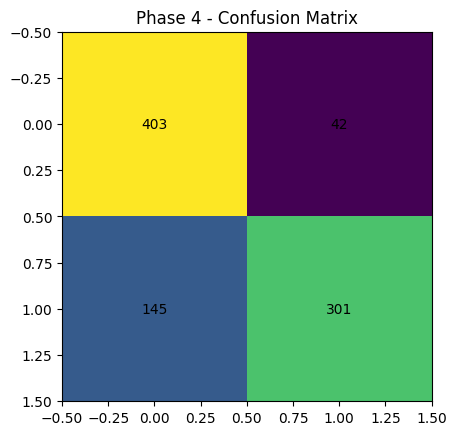

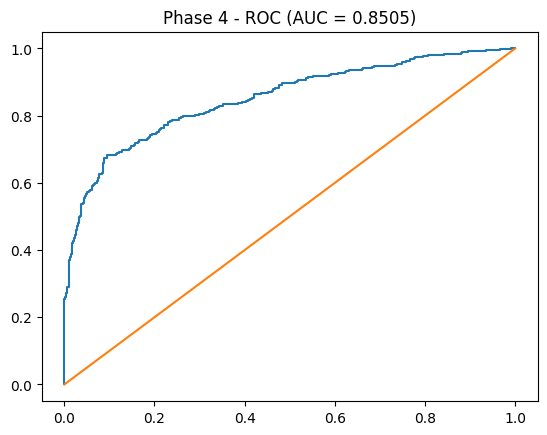

Phase 4 AUC: 0.8505265279387313


In [ ]:
evaluate_model(
    "/content/drive/MyDrive/phase4_best.pt",
    Phase4Model,
    "Phase 4"
)


# Confusion matrix and ROC curve

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

def evaluate_model(model_path, model_class, title):

    print(f"\nEvaluating {title}...\n")

    model = model_class().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_values, attention_mask)

            # Handle dictionary output (Phase 4)
            if isinstance(outputs, dict):
                logits = outputs["emotion_logits"]
            else:
                logits = outputs

            probs = torch.softmax(logits, dim=1)[:,1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # ==============================
    # Confusion Matrix
    # ==============================
    threshold = 0.5
    preds = (all_probs >= threshold).astype(int)

    cm = confusion_matrix(all_labels, preds)

    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title(f"{title} - Confusion Matrix ")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j],
                     horizontalalignment="center",
                     verticalalignment="center",
                     fontsize=14)

    plt.xticks([0,1])
    plt.yticks([0,1])
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    print(f"{title} Confusion Matrix:\n{cm}")

    # ==============================
    # ROC Curve
    # ==============================
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1])
    plt.title(f"{title} ROC Curve (AUC = {roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    print(f"{title} ROC AUC:", roc_auc)


Evaluating Transformer Baseline...



Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


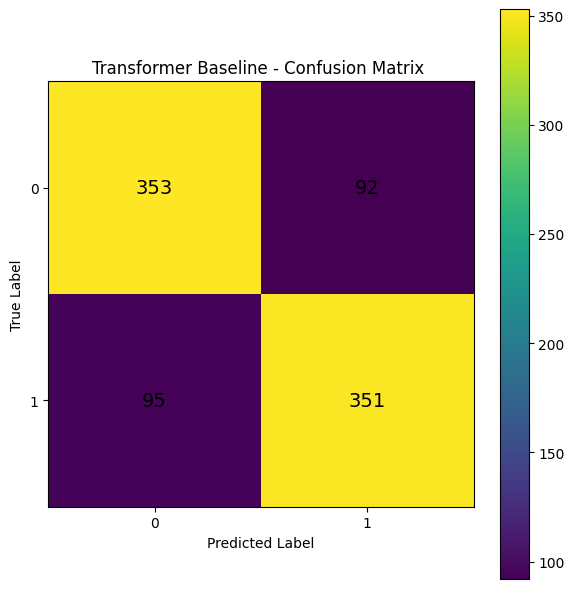

Transformer Baseline Confusion Matrix:
[[353  92]
 [ 95 351]]


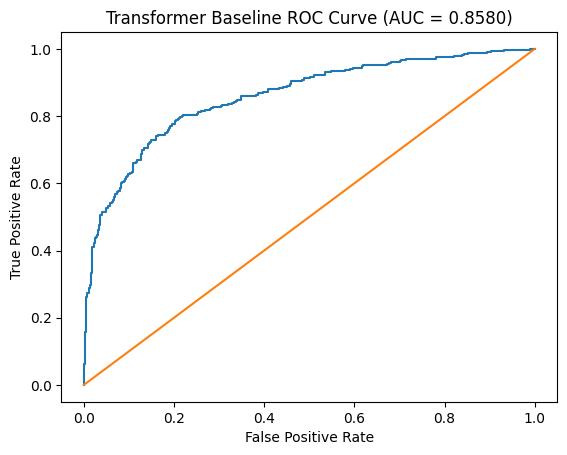

Transformer Baseline ROC AUC: 0.8579583816193884


In [ ]:
evaluate_model(
    "/content/drive/MyDrive/baseline_best.pt",
    BaselineModel,
    "Transformer Baseline"
)


Evaluating BiLSTM + Attention...



Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


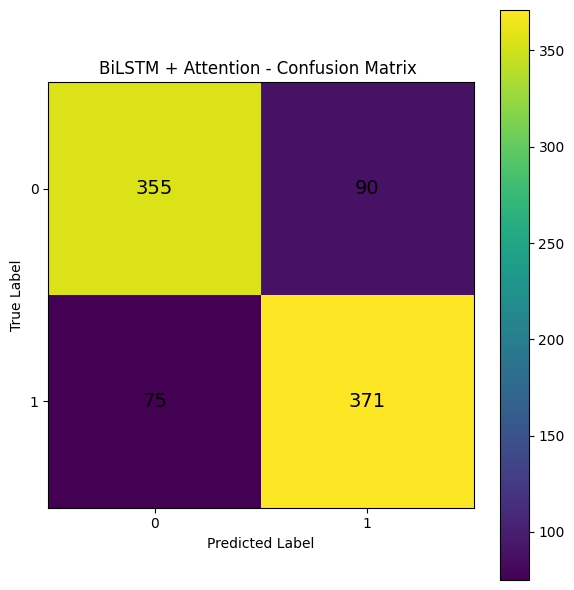

BiLSTM + Attention Confusion Matrix:
[[355  90]
 [ 75 371]]


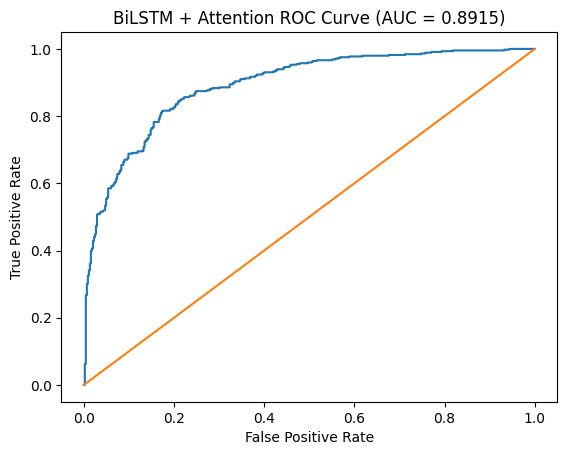

BiLSTM + Attention ROC AUC: 0.8914621857207639


In [ ]:
evaluate_model(
    "/content/drive/MyDrive/phase3_best.pt",
    Phase3Model,
    "BiLSTM + Attention"
)


Evaluating SDED-T (Cross-Entropy Only)...



Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


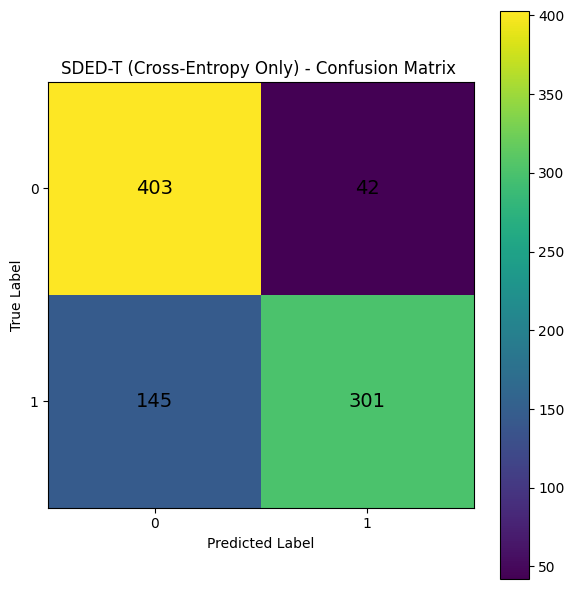

SDED-T (Cross-Entropy Only) Confusion Matrix:
[[403  42]
 [145 301]]


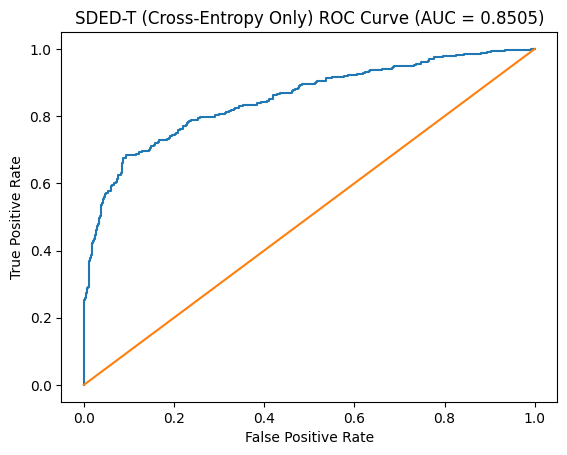

SDED-T (Cross-Entropy Only) ROC AUC: 0.8505265279387313


In [ ]:
evaluate_model(
    "/content/drive/MyDrive/phase4_best.pt",
    Phase4Model,
    "SDED-T (Cross-Entropy Only)"
)

In [ ]:
state_dict = torch.load("/content/drive/MyDrive/SDED_T_Final_Model.pt", map_location="cpu")

print("Saved Keys:\n")
for k in list(state_dict.keys())[:20]:
    print(k)


Saved Keys:

wav2vec.masked_spec_embed
wav2vec.feature_extractor.conv_layers.0.conv.weight
wav2vec.feature_extractor.conv_layers.0.layer_norm.weight
wav2vec.feature_extractor.conv_layers.0.layer_norm.bias
wav2vec.feature_extractor.conv_layers.1.conv.weight
wav2vec.feature_extractor.conv_layers.2.conv.weight
wav2vec.feature_extractor.conv_layers.3.conv.weight
wav2vec.feature_extractor.conv_layers.4.conv.weight
wav2vec.feature_extractor.conv_layers.5.conv.weight
wav2vec.feature_extractor.conv_layers.6.conv.weight
wav2vec.feature_projection.layer_norm.weight
wav2vec.feature_projection.layer_norm.bias
wav2vec.feature_projection.projection.weight
wav2vec.feature_projection.projection.bias
wav2vec.encoder.pos_conv_embed.conv.bias
wav2vec.encoder.pos_conv_embed.conv.parametrizations.weight.original0
wav2vec.encoder.pos_conv_embed.conv.parametrizations.weight.original1
wav2vec.encoder.layer_norm.weight
wav2vec.encoder.layer_norm.bias
wav2vec.encoder.layers.0.attention.k_proj.weight


In [ ]:
print("\nTask-specific keys:\n")
for k in state_dict.keys():
    if "bilstm" in k or "attention" in k or "shared" in k or "emotion" in k or "drift" in k or "confidence" in k:
        print(k)


Task-specific keys:

wav2vec.encoder.layers.0.attention.k_proj.weight
wav2vec.encoder.layers.0.attention.k_proj.bias
wav2vec.encoder.layers.0.attention.v_proj.weight
wav2vec.encoder.layers.0.attention.v_proj.bias
wav2vec.encoder.layers.0.attention.q_proj.weight
wav2vec.encoder.layers.0.attention.q_proj.bias
wav2vec.encoder.layers.0.attention.out_proj.weight
wav2vec.encoder.layers.0.attention.out_proj.bias
wav2vec.encoder.layers.1.attention.k_proj.weight
wav2vec.encoder.layers.1.attention.k_proj.bias
wav2vec.encoder.layers.1.attention.v_proj.weight
wav2vec.encoder.layers.1.attention.v_proj.bias
wav2vec.encoder.layers.1.attention.q_proj.weight
wav2vec.encoder.layers.1.attention.q_proj.bias
wav2vec.encoder.layers.1.attention.out_proj.weight
wav2vec.encoder.layers.1.attention.out_proj.bias
wav2vec.encoder.layers.2.attention.k_proj.weight
wav2vec.encoder.layers.2.attention.k_proj.bias
wav2vec.encoder.layers.2.attention.v_proj.weight
wav2vec.encoder.layers.2.attention.v_proj.bias
wav2vec.en

In [ ]:
import torch
import torch.nn as nn
from transformers import Wav2Vec2Model


class SDED_T(nn.Module):
    def __init__(self, num_classes=2):
        super(SDED_T, self).__init__()

        # ==============================
        # 1️⃣ Pretrained Wav2Vec2 Encoder
        # ==============================
        self.wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

        hidden_size = self.wav2vec.config.hidden_size

        # ==============================
        # 2️⃣ Bidirectional LSTM
        # ==============================
        self.bilstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        lstm_output_dim = 256 * 2  # because bidirectional

        # ==============================
        # 3️⃣ Attention Pooling
        # ==============================
        self.attention = nn.Sequential(
            nn.Linear(lstm_output_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # ==============================
        # 4️⃣ Shared Representation Layer
        # ==============================
        self.shared = nn.Sequential(
            nn.Linear(lstm_output_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        # ==============================
        # 5️⃣ Emotion Classification Head
        # ==============================
        self.emotion_head = nn.Linear(256, num_classes)

        # ==============================
        # 6️⃣ Drift Head (Regression)
        # ==============================
        self.drift_head = nn.Linear(256, 1)

        # ==============================
        # 7️⃣ Confidence Head
        # ==============================
        self.confidence_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, input_values, attention_mask=None):

        # ==============================
        # Wav2Vec2 Feature Extraction
        # ==============================
        outputs = self.wav2vec(
            input_values=input_values,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state  # (batch, time, hidden)

        # ==============================
        # BiLSTM Temporal Modeling
        # ==============================
        x, _ = self.bilstm(x)

        # ==============================
        # Attention Pooling
        # ==============================
        attn_scores = self.attention(x)
        attn_weights = torch.softmax(attn_scores, dim=1)
        x = torch.sum(attn_weights * x, dim=1)

        # ==============================
        # Shared Representation
        # ==============================
        shared = self.shared(x)

        # ==============================
        # Multi-Task Outputs
        # ==============================
        emotion_logits = self.emotion_head(shared)
        drift_score = self.drift_head(shared)
        confidence_score = self.confidence_head(shared)

        return {
            "emotion_logits": emotion_logits,
            "drift_score": drift_score,
            "confidence_score": confidence_score
        }

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SDED_T().to(device)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/SDED_T_Final_Model.pt", map_location=device)
)
model.eval()

SDED_T(
  (wav2vec): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): Wav2Vec

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

def evaluate_proposed_model(model, val_loader, device, threshold=0.5):

    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_values, attention_mask)
            logits = outputs["emotion_logits"]

            probs = torch.softmax(logits, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # =========================
    # Confusion Matrix
    # =========================
    preds = (all_probs >= threshold).astype(int)
    cm = confusion_matrix(all_labels, preds)

    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("SDED-T + SCMTL (Proposed) - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j],
                     horizontalalignment="center",
                     verticalalignment="center",
                     fontsize=14)

    plt.xticks([0,1])
    plt.yticks([0,1])
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    print("Confusion Matrix:\n", cm)

    # =========================
    # ROC Curve
    # =========================
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1])
    plt.title(f"SDED-T + SCMTL (Proposed) ROC Curve (AUC = {roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    print("ROC-AUC:", roc_auc)

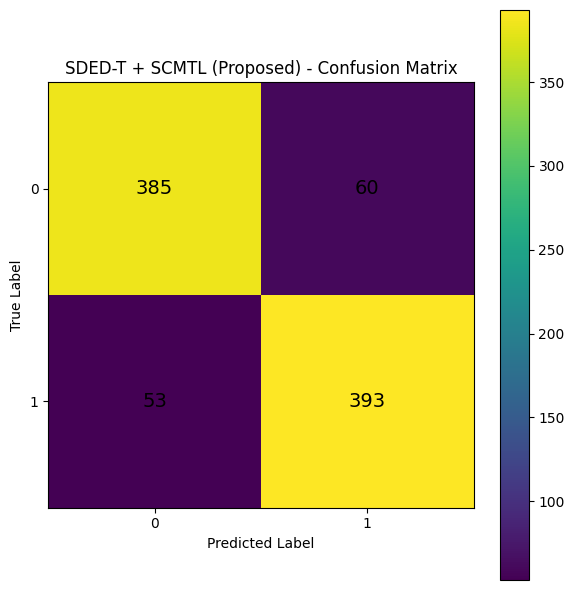

Confusion Matrix:
 [[385  60]
 [ 53 393]]


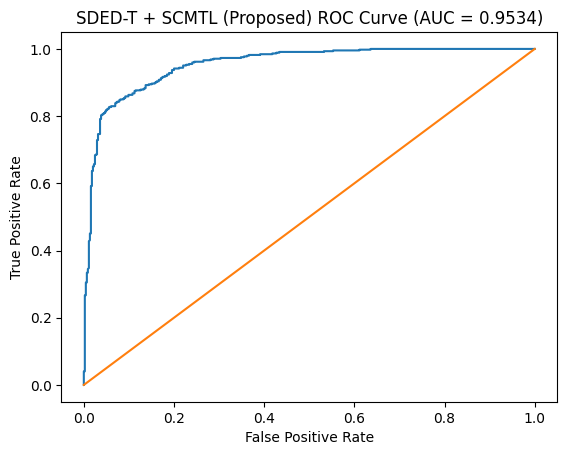

ROC-AUC: 0.9533783443341564


In [ ]:
evaluate_proposed_model(model, val_loader, device)